### Optimizacion de parametros para Mnist

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


from project.trained_models import load
from project.CROP.models.crop2 import Crop2 

dataset = "mnist"

cvae = load.cvae(inter=512,lat=128,dataset=dataset)
data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop2(cvae=cvae,predictor=predictor)

def objective(trial):

    bias = trial.suggest_float("bias", 0.1,5)
    slope = trial.suggest_float("slope", 10, 40)
    gamma = trial.suggest_float("gamma", 0.1, 1)
    alpha_1 = trial.suggest_float("alpha_1", -5, 0.5)
    alpha_2 = trial.suggest_float("alpha_2",-15 , -5)
    n_images=100
    try:        
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={"gamma": gamma,"bias":bias,"slope":slope, "alpha_1": alpha_1, "alpha_2": alpha_2},
            iterations=10,
            show_metrics=False
        )
        bpsnr = float(metrics["acc_both"])
        return  bpsnr

    except Exception as e:
        print(f"Error con bias={bias}, slope={slope}: {e}")
        return float("inf")
    

Usando mnist como dataset


In [24]:
import optuna


# Creamos un estudio de minimización
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=200) # Probamos 30 combinaciones

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)


[I 2025-12-12 00:44:31,730] A new study created in memory with name: no-name-ab4c67fd-4aae-446e-b5ba-418f5e45091b
[I 2025-12-12 00:44:34,219] Trial 0 finished with value: 0.13 and parameters: {'bias': 3.8448413691549894, 'slope': 20.549219063456558, 'gamma': 0.8578229179278124, 'alpha_1': -4.7450353043751425, 'alpha_2': -13.686074205268405}. Best is trial 0 with value: 0.13.
[I 2025-12-12 00:44:36,669] Trial 1 finished with value: 0.48 and parameters: {'bias': 0.7740522584657862, 'slope': 10.030167890810745, 'gamma': 0.9810756486165682, 'alpha_1': -4.548657734790021, 'alpha_2': -10.617188183628379}. Best is trial 1 with value: 0.48.
[I 2025-12-12 00:44:38,865] Trial 2 finished with value: 0.12 and parameters: {'bias': 3.5646861175971787, 'slope': 30.03117102725126, 'gamma': 0.8085174706246866, 'alpha_1': -2.099506611653191, 'alpha_2': -6.520729361021742}. Best is trial 1 with value: 0.48.
[I 2025-12-12 00:44:41,038] Trial 3 finished with value: 0.12 and parameters: {'bias': 1.991872076


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=137, state=1, values=[0.83], datetime_start=datetime.datetime(2025, 12, 12, 0, 49, 19, 425699), datetime_complete=datetime.datetime(2025, 12, 12, 0, 49, 21, 392591), params={'bias': 0.10424665898887171, 'slope': 21.5490849862168, 'gamma': 0.5181155795713602, 'alpha_1': -3.672001128760259, 'alpha_2': -8.807788417495047}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'bias': FloatDistribution(high=5.0, log=False, low=0.1, step=None), 'slope': FloatDistribution(high=40.0, log=False, low=10.0, step=None), 'gamma': FloatDistribution(high=1.0, log=False, low=0.1, step=None), 'alpha_1': FloatDistribution(high=0.5, log=False, low=-5.0, step=None), 'alpha_2': FloatDistribution(high=-5.0, log=False, low=-15.0, step=None)}, trial_id=137, value=None), FrozenTrial(number=181, state=1, values=[0.83], datetime_start=datetime.datetime(2025, 12, 12, 0, 50, 51, 274567), datetime_complete=datetime.datetime(2025, 12, 12, 

### separacion con los hiperparámetros encontrados.

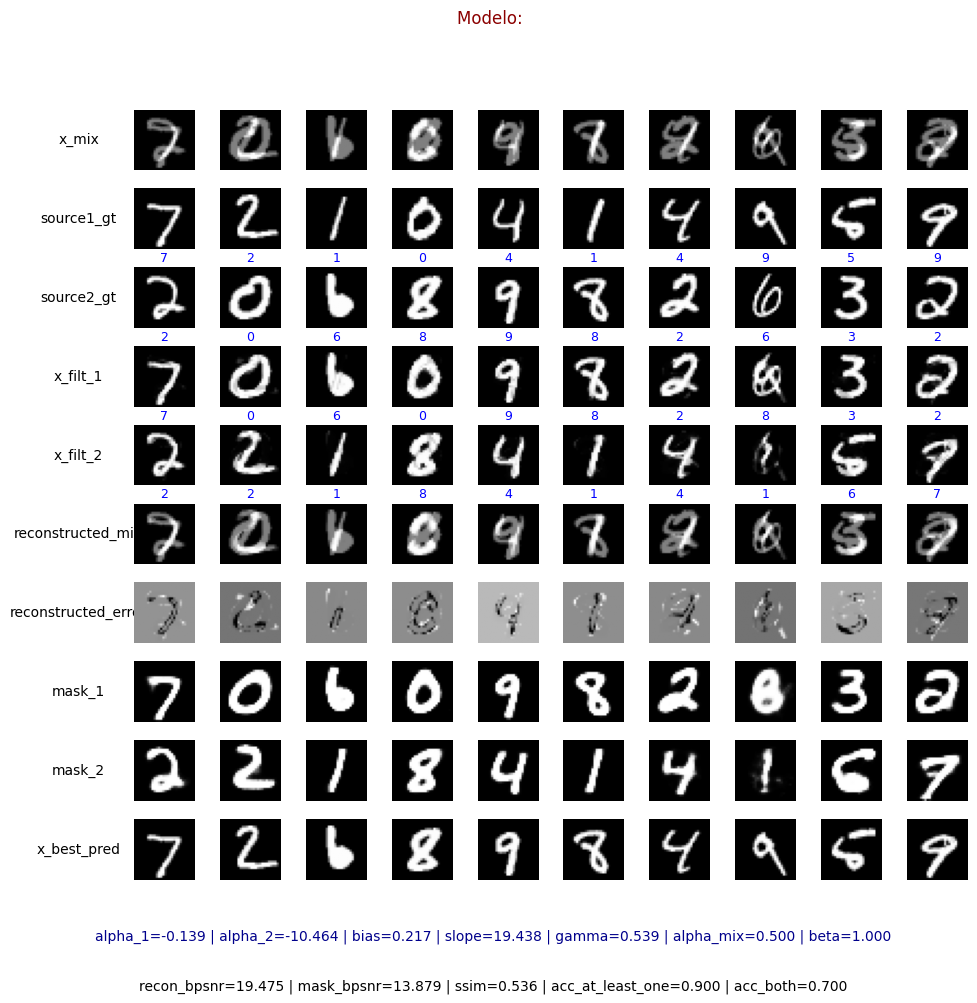

In [ ]:

n_image=10
labels=["0","1","2","3","4","5","6","7","8","9","0"]


#parámetros optimizados para ssim
ssim_params={'bias': 0.3490758398711943, 'slope': 23.79981809771706, 'alpha_1': -2.5004348572265864, 'alpha_2': -16.418488717733673, 'gamma': 0.2612293606781744}
#parámetros optimizados para recon_bpsnr
recon_bpsnr_params={'bias': 0.1753106428802752, 'slope': 20.088006577214188, 'alpha_1': -4.3120902863188775, 'alpha_2': -31.469765177549906, 'gamma': 0.7367839585631266}
#parámetros optimizados para mask_bpsnr
mask_bpsnr_params={'bias': 0.4032196468954787, 'slope': 10.773311686035228, 'alpha_1': -4.487552303478556, 'alpha_2': -7.255734630588293, 'gamma': 0.44933267965195817}#parámetros optimizados para acc_both
#parámetros optimizados para acc_both
acc_both_params={'bias': 0.21716868437244724, 'slope': 19.437646607877017, 'alpha_1': -0.13863158439804657, 'alpha_2': -10.463749682840565, 'gamma': 0.5392507616026618}
## solo optimizanddo gamma
acc_both_gamma = {'gamma': 0.7435064454594396}

##recon_bpsnr lat128_inter_512
params_recon_bpsnr_lat128_inter_512={'gamma': 0.9519615639307367}#optimizacion para recon_bpsnr
params_acc_both_lat128_inter_512 = {'gamma': 0.3012911033494221} # optimización de acc
#acc_both bias y slope y gamma 

results = c.unmix(
    x_test[:n_image],
    x_test_1[:n_image],
    y_test[:n_image],
    y_test_1[:n_image],
    #params={'bias': 0.17786223110878405, 'slope': 24.277471484785064, 'gamma': 0.4665746345952185},
    params = acc_both_params,
    iterations=10,
    show_image=True,
    show_metrics=False,
    labels=labels
)


### Prueba para fashion

In [9]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.trained_models import load
from project.CROP.models.crop2 import Crop2 

dataset = "fashion"

cvae = load.cvae(inter=256,lat=64,dataset=dataset)
data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop2(cvae=cvae,predictor=predictor)

def objective(trial):

    #bias = trial.suggest_float("bias", 0.1,0.99)
    #slope = trial.suggest_float("slope", 10, 40)
    #alpha_1 = trial.suggest_float("alpha_1", -5, -0.1)
    #alpha_2 = trial.suggest_float("alpha_2", -40, -5)
    gamma = trial.suggest_float("gamma", 0.1, 1)
    n_images=100
    try:        
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={"gamma": gamma},
            iterations=10,
            show_metrics=False
        )
        met = float(metrics["recon_bpsnr"][0])
        return met  

    except Exception as e:
        print(f"Error con bias={bias}, slope={slope}: {e}")
        return float("inf")

Usando fashion como dataset


In [10]:
import optuna

# Creamos un estudio de minimización
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=200) # Probamos 30 combinaciones

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)


[I 2025-12-12 00:13:51,932] A new study created in memory with name: no-name-708074b9-8b4a-4ea4-b276-34309883d3b8
[I 2025-12-12 00:13:52,970] Trial 0 finished with value: 17.86210060119629 and parameters: {'gamma': 0.7172196492580329}. Best is trial 0 with value: 17.86210060119629.
[I 2025-12-12 00:13:53,927] Trial 1 finished with value: 17.28643226623535 and parameters: {'gamma': 0.48651234700899426}. Best is trial 0 with value: 17.86210060119629.
[I 2025-12-12 00:13:54,852] Trial 2 finished with value: 16.857898712158203 and parameters: {'gamma': 0.32508739881742427}. Best is trial 0 with value: 17.86210060119629.
[I 2025-12-12 00:13:55,773] Trial 3 finished with value: 17.485830307006836 and parameters: {'gamma': 0.5633932864520983}. Best is trial 0 with value: 17.86210060119629.
[I 2025-12-12 00:13:56,699] Trial 4 finished with value: 18.057506561279297 and parameters: {'gamma': 0.8426064087804859}. Best is trial 4 with value: 18.057506561279297.
[I 2025-12-12 00:13:57,613] Trial 5


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=74, state=1, values=[18.262861251831055], datetime_start=datetime.datetime(2025, 12, 12, 0, 15, 40, 59726), datetime_complete=datetime.datetime(2025, 12, 12, 0, 15, 42, 111179), params={'gamma': 0.9999917168554645}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'gamma': FloatDistribution(high=1.0, log=False, low=0.1, step=None)}, trial_id=74, value=None)]


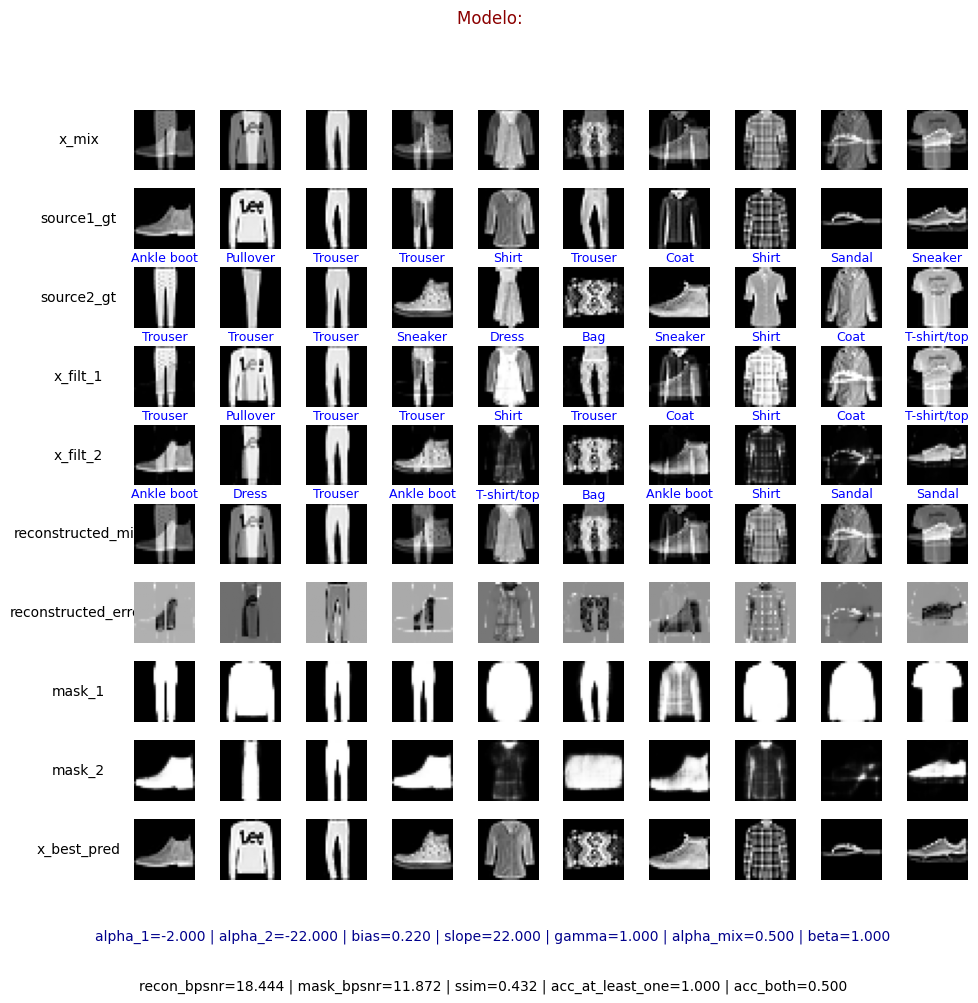


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -2.000
alpha_2   : -22.000
bias      : 0.220
slope     : 22.000
gamma     : 1.000
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.444  std:3.890
mask_bpsnr       : mean: 11.872  std:2.121
ssim             : mean: 0.432  std:0.208
acc_at_least_one : 1.000
acc_both         : 0.500



In [11]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
import numpy as np
np.random.seed(0)
n_image=10
labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

#parámetros optimizados para ssim
ssim_params={'bias': 0.30550641418749014, 'slope': 18.184530449530822, 'alpha_1': -1.3880813558028482, 'alpha_2': -23.23869929458664, 'gamma': 0.158635364906733}
#parámetros optimizados para recon_bpsnr
recon_bpsnr_params={'bias': 0.1943216020281843, 'slope': 13.31893832689755, 'alpha_1': -4.404314358094745, 'alpha_2': -18.09515909301692, 'gamma': 0.9988131660741272}
#parámetros optimizados para mask_bpsnr
mask_bpsnr_params={'bias': 0.3612215771996162, 'slope': 10.386990400185999, 'alpha_1': -2.2836306091361522, 'alpha_2': -39.106900020010485, 'gamma': 0.28567901820069325}
#parámetros optimizados para acc_both
acc_both_params={'bias': 0.21448091402310066, 'slope': 16.357665616536412, 'alpha_1': -4.167773572199956, 'alpha_2': -34.5165642267941, 'gamma': 0.5801985736319661}
#
only_gamma_params={'gamma': 0.49059568485187854}

only_gamma_params={'gamma': 1}


metrics=c.unmix(
    x_test[:n_image],
    x_test_1[:n_image],
    y_test[:n_image],
    y_test_1[:n_image],
    params=only_gamma_params,
    iterations=10,
    show_image=True,
    labels=labels
)


### Prueba para mnist

Con los datos de MNIST no se obseva la sturación de las máscaras pro quelos digitos tiene menos "gris".


## Metricas de Accq para un digito y dos

Usando valores de 'bias': 0.22, 'slope': 22
Usando valores de 'bias': 0.2562, 'slope': 10.0067


In [13]:
def filtrar_imagenes_con_max255():
    """
    Filtra las imágenes de los datasets Fashion-MNIST y MNIST que contienen al menos un píxel con valor 255,
    y aquellas que no contienen ningún píxel con valor 255.
    
    Returns:
    - x_train_fashion, y_train_fashion, x_test_fashion, y_test_fashion: Arrays filtrados de Fashion-MNIST.
    - x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist: Arrays filtrados de MNIST.
    """
    from tensorflow.keras.datasets import fashion_mnist, mnist
    import numpy as np

    # Cargar Fashion-MNIST
    (x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()

    # Filtrar imágenes de entrenamiento de Fashion-MNIST
    mask_train_fashion = np.any(x_train_fashion == 255, axis=(1, 2))
    x_train_fashion_con255 = x_train_fashion[mask_train_fashion]
    y_train_fashion_con255 = y_train_fashion[mask_train_fashion]
    x_train_fashion_sin255 = x_train_fashion[~mask_train_fashion]
    y_train_fashion_sin255 = y_train_fashion[~mask_train_fashion]

    # Filtrar imágenes de prueba de Fashion-MNIST
    mask_test_fashion = np.any(x_test_fashion == 255, axis=(1, 2))
    x_test_fashion_con255 = x_test_fashion[mask_test_fashion]
    y_test_fashion_con255 = y_test_fashion[mask_test_fashion]
    x_test_fashion_sin255 = x_test_fashion[~mask_test_fashion]
    y_test_fashion_sin255 = y_test_fashion[~mask_test_fashion]

    # Cargar MNIST
    (x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

    # Filtrar imágenes de entrenamiento de MNIST
    mask_train_mnist = np.any(x_train_mnist == 255, axis=(1, 2))
    x_train_mnist_con255 = x_train_mnist[mask_train_mnist]
    y_train_mnist_con255 = y_train_mnist[mask_train_mnist]
    x_train_mnist_sin255 = x_train_mnist[~mask_train_mnist]
    y_train_mnist_sin255 = y_train_mnist[~mask_train_mnist]

    # Filtrar imágenes de prueba de MNIST
    mask_test_mnist = np.any(x_test_mnist == 255, axis=(1, 2))
    x_test_mnist_con255 = x_test_mnist[mask_test_mnist]
    y_test_mnist_con255 = y_test_mnist[mask_test_mnist]
    x_test_mnist_sin255 = x_test_mnist[~mask_test_mnist]
    y_test_mnist_sin255 = y_test_mnist[~mask_test_mnist]

    return {
        'fashion_mnist': {
            'train_con255': (x_train_fashion_con255, y_train_fashion_con255),
            'train_sin255': (x_train_fashion_sin255, y_train_fashion_sin255),
            'test_con255': (x_test_fashion_con255, y_test_fashion_con255),
            'test_sin255': (x_test_fashion_sin255, y_test_fashion_sin255)
        },
        'mnist': {
            'train_con255': (x_train_mnist_con255, y_train_mnist_con255),
            'train_sin255': (x_train_mnist_sin255, y_train_mnist_sin255),
            'test_con255': (x_test_mnist_con255, y_test_mnist_con255),
            'test_sin255': (x_test_mnist_sin255, y_test_mnist_sin255)
        }
    }

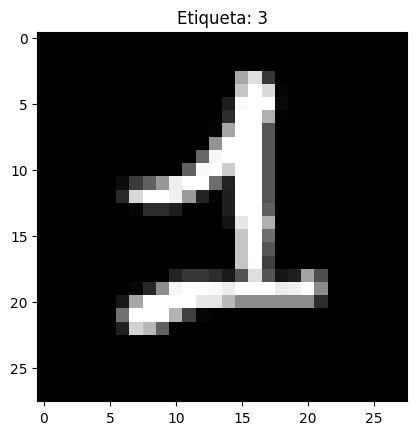

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist, mnist

# Cargar el conjunto de datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Filtrar imágenes sin píxeles con valor 255
mask_train_sin255 = np.all(x_train != 255, axis=(1, 2))
x_train_sin255 = x_train[mask_train_sin255]
y_train_sin255 = y_train[mask_train_sin255]

# Verificar si hay imágenes sin píxeles con valor 255
if x_train_sin255.shape[0] > 0:
    # Mostrar la primera imagen sin píxeles con valor 255
    plt.imshow(x_train_sin255[1], cmap='gray')
    plt.title(f"Etiqueta: {y_train_sin255[0]}")
    plt.show()
else:
    print("No se encontraron imágenes sin píxeles con valor 255.")


print(x_train_sin255[0])

En ambos datasets hay imagenes sin 255. El problema de la imagen duplicada tiene que ver con el modelo, no con el dataset.

Evaluación de métricas

## Funcionamiento de optuna

Libreria de optimizacion de hiperparametos.
busqueda inteligente en lugar de grid search. --> optimizar hiperparametros que probablemente mejoren resultados.

Trail --> Prueba
Study --> Colección de Trails
Objective funtion --> Función a optimizar. 

Algoritmo principal. TPE. (Tree-structure Parzen Estimator). Método bayesiano que aprende de resultados anteriores para elegir parametros. 

-------------------------------------------------------------------------------------------

## TPE
"Dado un valor de la función objetivo ¿Qué distribución de hiperparametros de más probable?"
- Se guardan los Trails (hiperparametros y resultados)
- Se dividen 2 grupos. l(x): Distribución de hiperparámetros que dieron buenos resulados y g(x):  Distribución de hiperparámetros que dieron malos resulados
- Para cada hiperparámetro TPE construye dos distribuciones. ¿Cómo son los hiper cuando los resultados son buenos y cuando malos?. Estimadores de Parzen. 
- El algoritmo elige nuevos valores de hiperparametros maximizando l(x)/g(x)
- Se vuelve a probar y ajustar l(x) y g(x)

## Estimadores tipo Parzen
Estimador de densidad para obtener una aproximación de una curva suave que estima la PDF de los hiperparametros.

- Cada muestra que dio un valor bueno se "transforma" en una distribución local (una gaussiana centrada en ese valor)
- Para un punto x la densidad estimada es 
$ f(x) = \frac{1}{nh} \sum_{i=1}^n K \left( \frac{x-x_i}{h} \right)$
n: número de muestras
h: ancho de la ventana  
K: kernel 

- La suma de todas las gaussianas producen una curva suave que representan probabilidades.


